# Notebook Klasifikasi Kematangan Pisang
**ConvNeXt-Tiny** vs **MobileNetV3-Large**

## Tahap 1: Import Library

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

print("TensorFlow Version:", tf.__version__)

2026-05-29 06:46:13.646130: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780037173.827935      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780037173.879282      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780037174.314412      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780037174.314478      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780037174.314488      23 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


## Tahap 2: Memuat dan Mempersiapkan Dataset

In [2]:
DATASET_PATH = '/kaggle/input/datasets/erlinsariramadhani/dataset-kematangan-pisang'

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Memuat Data Latih (Training)...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

print("\nMemuat Data Validasi...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("\nKelas yang terdeteksi:", class_names)

Memuat Data Latih (Training)...
Found 300 files belonging to 3 classes.
Using 240 files for training.


I0000 00:00:1780037189.634475      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780037189.640436      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Memuat Data Validasi...
Found 300 files belonging to 3 classes.
Using 60 files for validation.

Kelas yang terdeteksi: ['matang', 'mentah', 'terlalu_matang']


## Tahap 3: Augmentasi Data (On-The-Fly) dan Optimasi Pipeline Data

In [3]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1)
], name="Augmentasi_On_The_Fly")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("Pipa Data & Augmentasi siap!")

Pipa Data & Augmentasi siap!


## Tahap 4: Membangun Arsitektur Model (Transfer Learning)

In [4]:
def build_convnext_tiny(num_classes):
    base_model = tf.keras.applications.ConvNeXtTiny(
        include_top=False, weights='imagenet', input_shape=(224, 224, 3)
    )
    base_model.trainable = False
    
    inputs = keras.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.convnext.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return keras.Model(inputs, outputs, name="ConvNeXt_Tiny")

def build_mobilenet_v3(num_classes):
    base_model = tf.keras.applications.MobileNetV3Large(
        include_top=False, weights='imagenet', input_shape=(224, 224, 3)
    )
    base_model.trainable = False 
    
    inputs = keras.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v3.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return keras.Model(inputs, outputs, name="MobileNetV3_Large")

## Tahap 5: Kompilasi Model

In [5]:
model_convnext = build_convnext_tiny(NUM_CLASSES)
model_mobilenet = build_mobilenet_v3(NUM_CLASSES)

learning_rate = 0.001

model_convnext.compile(
    optimizer=keras.optimizers.Adam(learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mobilenet.compile(
    optimizer=keras.optimizers.Adam(learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model siap dilatih!")
model_convnext.summary()

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model siap dilatih!


Model: "ConvNeXt_Tiny"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Augmentasi_On_The_Fly           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,918,947 (106.50 MB)

 Trainable params: 98,819 (386.01 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

## Tahap 6: Training Model ConvNeXt-Tiny

In [6]:
EPOCHS = 20

callbacks_conv = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_convnext_pisang.h5', monitor='val_accuracy', save_best_only=True)
]

print("Memulai Training ConvNeXt-Tiny...")
history_convnext = model_convnext.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_conv
)

Memulai Training ConvNeXt-Tiny...
Epoch 1/20


I0000 00:00:1780037209.009627      74 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780037210.513738      74 service.cc:152] XLA service 0x7e3891f11eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780037210.513782      74 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780037210.513790      74 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780037211.006946      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-05-29 06:46:55.705174: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 06:46:55.839667: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured t

7/8 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4133 - loss: 1.1497

2026-05-29 06:47:09.695775: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 06:47:09.844620: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-29 06:47:09.978555: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4236 - loss: 1.1312

...

8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9667 - loss: 0.1916 - val_accuracy: 0.7333 - val_loss: 0.4819
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9852 - loss: 0.1140

8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9750 - loss: 0.1179 - val_accuracy: 0.7667 - val_loss: 0.4854
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9832 - loss: 0.1081

8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9708 - loss: 0.1148 - val_accuracy: 0.8667 - val_loss: 0.3567
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9792 - loss: 0.0889 - val_accuracy: 0.8667 - val_loss: 0.2823
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9875 - loss: 0.0768 - val_accuracy: 0.8333 - val_loss: 0.3742
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 1.0000 - loss: 0.0442 - val_accuracy: 0.8667 - val_loss: 0.3110
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9837 - loss: 0.0700

8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9792 - loss: 0.0727 - val_accuracy: 0.9500 - val_loss: 0.1496
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9958 - loss: 0.0464 - val_accuracy: 0.9333 - val_loss: 0.1987
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9917 - loss: 0.0474 - val_accuracy: 0.9500 - val_loss: 0.1574
Epoch 13/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9833 - loss: 0.0533 - val_accuracy: 0.8833 - val_loss: 0.2692
Epoch 14/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9958 - loss: 0.0310 - val_accuracy: 0.9500 - val_loss: 0.1428
Epoch 15/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 1.0000 - loss: 0.0322 - val_accuracy: 0.8833 - val_loss: 0.2680
Epoch 16/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9989 - loss: 0.0354

8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9958 - loss: 0.0365 - val_accuracy: 0.9833 - val_loss: 0.1256
Epoch 17/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9917 - loss: 0.0389 - val_accuracy: 0.9000 - val_loss: 0.2209
Epoch 18/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9917 - loss: 0.0306 - val_accuracy: 0.9333 - val_loss: 0.1904
Epoch 19/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 1.0000 - loss: 0.0222 - val_accuracy: 0.9833 - val_loss: 0.1032
Epoch 20/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9958 - loss: 0.0250 - val_accuracy: 0.9500 - val_loss: 0.1742


## Tahap 7: Training Model MobileNetV3-Large

In [7]:
callbacks_mob = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_mobilenet_pisang.h5', monitor='val_accuracy', save_best_only=True)
]

print("\nMemulai Training MobileNetV3-Large...")
history_mobilenet = model_mobilenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_mob
)


Memulai Training MobileNetV3-Large...
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6584 - loss: 0.8920

8/8 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.8042 - loss: 0.5863 - val_accuracy: 0.9500 - val_loss: 0.1991
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9604 - loss: 0.1393

8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9708 - loss: 0.1098 - val_accuracy: 1.0000 - val_loss: 0.0468
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9792 - loss: 0.0688 - val_accuracy: 1.0000 - val_loss: 0.0356
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9917 - loss: 0.0266 - val_accuracy: 0.9833 - val_loss: 0.0454
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9958 - loss: 0.0167 - val_accuracy: 1.0000 - val_loss: 0.0089
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9958 - loss: 0.0227 - val_accuracy: 1.0000 - val_loss: 0.0081
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9958 - loss: 0.0119 - val_accuracy: 1.0000 - val_loss: 0.0121
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 0.0088
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 1.0000 - loss: 0.0057 - val_accuracy: 1.0000 - val_loss: 0.0071
Epoch 10/20
8/8 ━━━

## Tahap 8: Visualisasi Hasil Training (Grafik Akurasi & Loss)

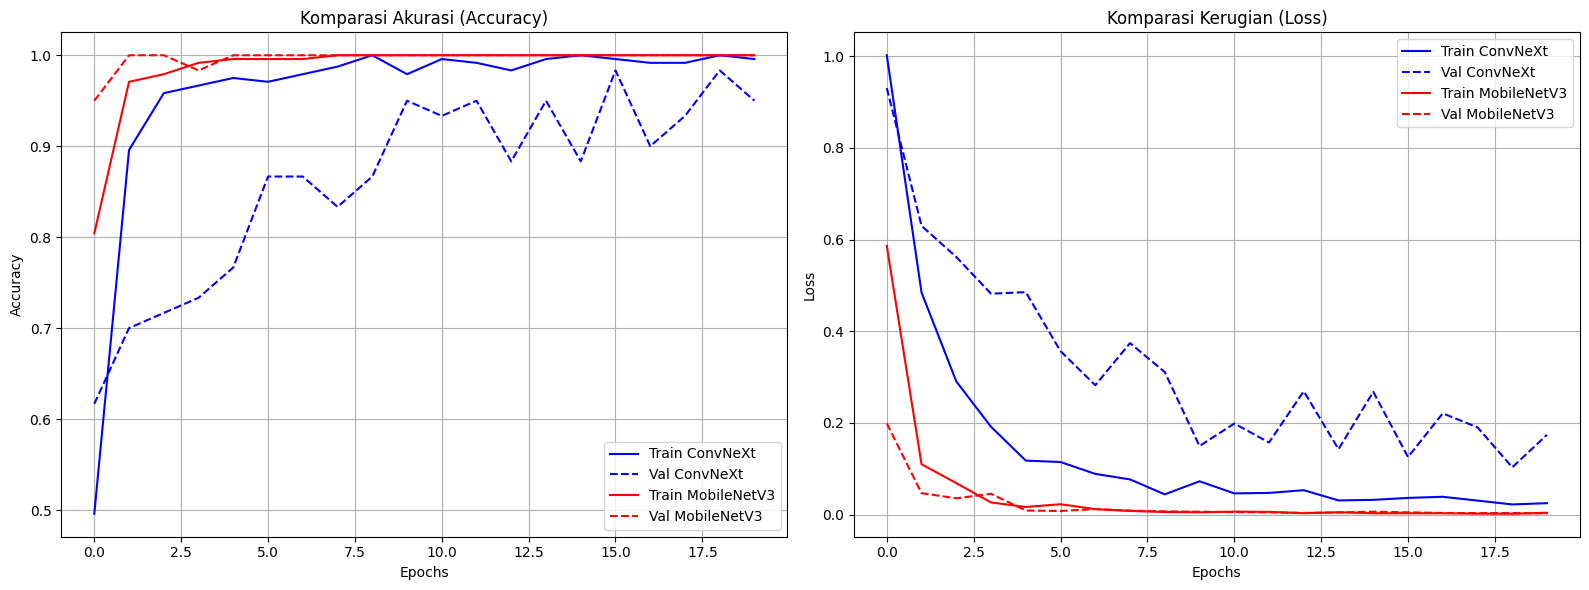

In [8]:
def plot_history(hist1, hist2, title1, title2):
    plt.figure(figsize=(16, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(hist1.history['accuracy'], label=f'Train {title1}', color='blue', linestyle='-')
    plt.plot(hist1.history['val_accuracy'], label=f'Val {title1}', color='blue', linestyle='--')
    plt.plot(hist2.history['accuracy'], label=f'Train {title2}', color='red', linestyle='-')
    plt.plot(hist2.history['val_accuracy'], label=f'Val {title2}', color='red', linestyle='--')
    plt.title('Komparasi Akurasi (Accuracy)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(hist1.history['loss'], label=f'Train {title1}', color='blue', linestyle='-')
    plt.plot(hist1.history['val_loss'], label=f'Val {title1}', color='blue', linestyle='--')
    plt.plot(hist2.history['loss'], label=f'Train {title2}', color='red', linestyle='-')
    plt.plot(hist2.history['val_loss'], label=f'Val {title2}', color='red', linestyle='--')
    plt.title('Komparasi Kerugian (Loss)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_history(history_convnext, history_mobilenet, "ConvNeXt", "MobileNetV3")

## Tahap 9: Evaluasi Model dengan Confusion Matrix dan Classification Report

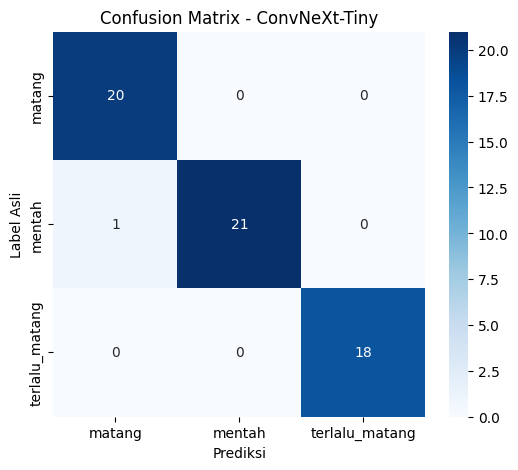


Laporan Klasifikasi Confusion Matrix - ConvNeXt-Tiny:

                precision    recall  f1-score   support

        matang       0.95      1.00      0.98        20
        mentah       1.00      0.95      0.98        22
terlalu_matang       1.00      1.00      1.00        18

      accuracy                           0.98        60
     macro avg       0.98      0.98      0.98        60
  weighted avg       0.98      0.98      0.98        60



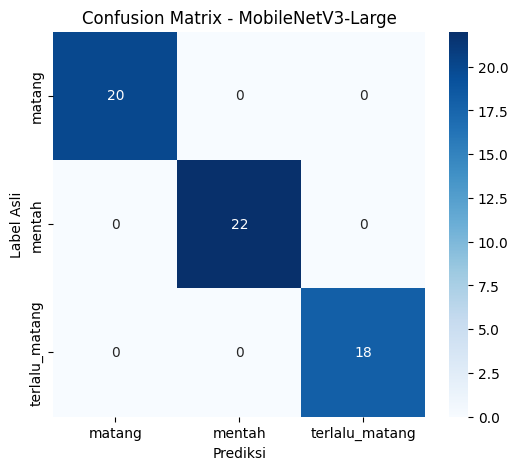


Laporan Klasifikasi Confusion Matrix - MobileNetV3-Large:

                precision    recall  f1-score   support

        matang       1.00      1.00      1.00        20
        mentah       1.00      1.00      1.00        22
terlalu_matang       1.00      1.00      1.00        18

      accuracy                           1.00        60
     macro avg       1.00      1.00      1.00        60
  weighted avg       1.00      1.00      1.00        60



In [9]:
y_true = []
y_pred_conv = []
y_pred_mob = []

for images, labels in val_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=-1))

    pred_c = model_convnext.predict(images, verbose=0)
    pred_m = model_mobilenet.predict(images, verbose=0)
    
    y_pred_conv.extend(np.argmax(pred_c, axis=-1))
    y_pred_mob.extend(np.argmax(pred_m, axis=-1))

y_true = np.array(y_true)
y_pred_conv = np.array(y_pred_conv)
y_pred_mob = np.array(y_pred_mob)

def plot_cm(y_t, y_p, title):
    cm = confusion_matrix(y_t, y_p, labels=range(NUM_CLASSES))
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Label Asli')
    plt.xlabel('Prediksi')
    plt.show()
    
    print(f"\nLaporan Klasifikasi {title}:\n")
    print(classification_report(y_t, y_p, target_names=class_names, labels=range(NUM_CLASSES), zero_division=0))

plot_cm(y_true, y_pred_conv, "Confusion Matrix - ConvNeXt-Tiny")
plot_cm(y_true, y_pred_mob, "Confusion Matrix - MobileNetV3-Large")
